<a href="https://colab.research.google.com/github/Janeth172/Simu-I/blob/main/CLASE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CLASE**

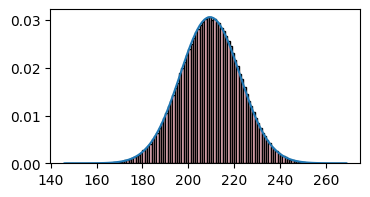

187.0 230.0
208.975926


In [2]:
from random import random
from math import log,sqrt,exp,pi
from numba import jit
import matplotlib.pyplot as plt
import numpy as np
@jit(nopython=True)

# genera nr simulaciones del número de personas atendidas en el intervalo [0,T]
def f(T,nr):
    ll = np.zeros(nr)
    for i in range(nr):
        l_l = 2      # tasa de llegadas (lambda)
        l_s = 1.8    # tasa de servicio (mu)
        t = 0        # tiempo actual
        infi = 100000000
        ts = infi    # tiempo próxima salida
        tl = 0       # tiempo próxima llegada
        l = 0        # número de personas en sistema
        cuenta = 0   # número atendido

        while min(tl,ts)<T:       #Simulación basada en eventos
            # próxima llegada → tl
            # próxima salida → ts
            t = min(tl,ts)

            # Caso 1: llegada
            if t == tl:
                l = l+1       # llega un cliente → aumenta la cola
                #print("%10.3f"%tl,l)
                tl = t - (1/l_l) * log(random())    # Generar siguiente llegada

                # Si el sistema estaba vacío, empieza servicio inmediatamente
                if l == 1:
                    ts = t - (1/l_s) * log(random())

            # Caso 2: salida
            else:
                l = l-1
                cuenta = cuenta+1     # alguien termina → lo cuentas
                #print("         ", "%10.3f"ts, l)

                # Si ya no hay clientes
                if l == 0:
                    ts = infi     # no hay servicio en curso
                # Si quedan clientes
                else:
                    ts = t - (1./l_s) * log(random()) # siguiente servicio

        # Guardar resultado
        ll[i] = cuenta    # número de personas atendidas en esa simulación
    return ll

# Parámetros y simulación
nr = 1000000        # Repetir el experimento 1 millón de veces
T = 120             # Tiempo total de observación
ll = f(T,nr)        # ll=[N1​(120),N2​(120),...,N1000000​(120)]

# Construcción de los “bins” del histograma
b = []
x = np.min(ll)      # Menor número de atendidos observado
lim = np.max(ll)    # Mayor número observado

# Crear b=[min,min+1,min+2,...,max−1]
while x < lim:
    b.append(x)
    x = x+1
lt = []       # curva teórica aproximada (normal)

# Cálculo de media y varianza
media = np.mean(ll)
var = np.var(ll)

# Aproximación normal
# f(x) = 1 / sqrt(2π·var) · exp( - (x - media)^2 / (2·var) )
for x in b:
    lt.append((1/(sqrt(2*pi*var)))*exp(-(x-.5-media)**2/(2*var)))

plt.figure(figsize=(4,2))
plt.hist(ll,density=1, bins=b, color='pink', edgecolor='black')
plt.plot(b,lt)
plt.show()
print(np.quantile(ll,.05),np.quantile(ll,.95))
print(np.mean(ll))